### Plotting the Normalised Frequency for ech length in query.bed

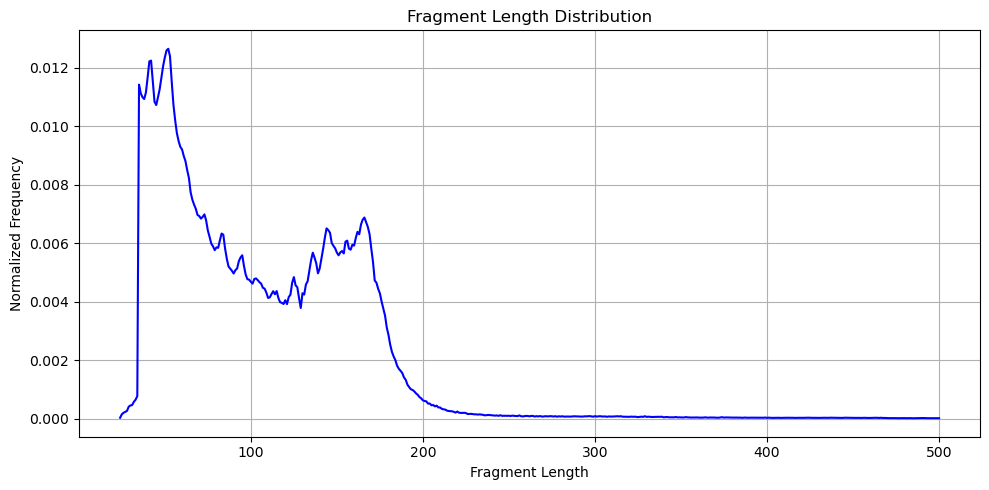

In [1]:
import matplotlib.pyplot as plt
from collections import defaultdict

fragment_counts = defaultdict(int)
total_fragments = 0

# Read and process BED file
with open("query.bed", "r") as f:
    for line in f:
        cols = line.strip().split()
        if len(cols) < 3:
            continue
        try:
            start = int(cols[1])
            end = int(cols[2])
            length = end - start
            if length > 0:
                fragment_counts[length] += 1
                total_fragments += 1
        except ValueError:
            continue

# Compute normalized frequencies
lengths = sorted(fragment_counts)
normalized_freqs = [fragment_counts[l] / total_fragments for l in lengths]

# Plot fragment length distribution
plt.figure(figsize=(10, 5))
plt.plot(lengths, normalized_freqs, color="blue", linewidth=1.5)
plt.xlabel("Fragment Length")
plt.ylabel("Normalized Frequency")
plt.title("Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


### Rescaling of query along the reference

In [2]:
reference_distribution = {}

# Read and parse the reference histogram file
with open("reference.hist", "r") as ref_file:
    for line in ref_file:
        parts = line.strip().split()
        if len(parts) != 2:
            continue  # skip malformed lines
        try:
            length = int(parts[0])
            freq = float(parts[1])
            reference_distribution[length] = freq
        except ValueError:
            continue  # skip lines with invalid numbers

# Normalize the frequencies
total_ref_freq = sum(reference_distribution.values())
normalized_ref = {
    length: freq / total_ref_freq
    for length, freq in reference_distribution.items()
}


In [3]:
from collections import defaultdict

query_fragments = defaultdict(list)

# Read and process the query BED file
with open("query.bed", "r") as f:
    for line in f:
        cols = line.strip().split()
        if len(cols) < 3:
            continue  # skip lines with insufficient columns
        try:
            start = int(cols[1])
            end = int(cols[2])
            length = end - start
            if length > 0:
                query_fragments[length].append(line.strip())
        except ValueError:
            continue  # skip lines with invalid integer values

# Calculate total fragments in the query data
max_fragments = sum(len(v) for v in query_fragments.values())


In [4]:
import random

resampled_fragments = []

# Resample fragments based on the normalized reference distribution
for length, target_frac in normalized_ref.items():
    if length in query_fragments:
        available = query_fragments[length]
        target_count = int(round(target_frac * max_fragments))

        # Avoid resampling more than the available fragments
        sampled_count = min(target_count, len(available))

        # Sample the available fragments (without exceeding the available number)
        sampled = random.sample(available, sampled_count)

        # Add the sampled fragments to the result
        resampled_fragments.extend(sampled)


In [5]:
from collections import defaultdict

# Count the occurrences of each fragment length in the resampled fragments
resampled_counts = defaultdict(int)

for line in resampled_fragments:
    cols = line.strip().split()
    try:
        length = int(cols[2]) - int(cols[1])
        resampled_counts[length] += 1
    except ValueError:
        continue  # Skip lines with invalid data

# Calculate total number of resampled fragments
total_resampled = sum(resampled_counts.values())

# Sort fragment lengths and calculate normalized frequencies
x_vals = sorted(resampled_counts.keys())
y_vals = [resampled_counts[x] / total_resampled for x in x_vals]


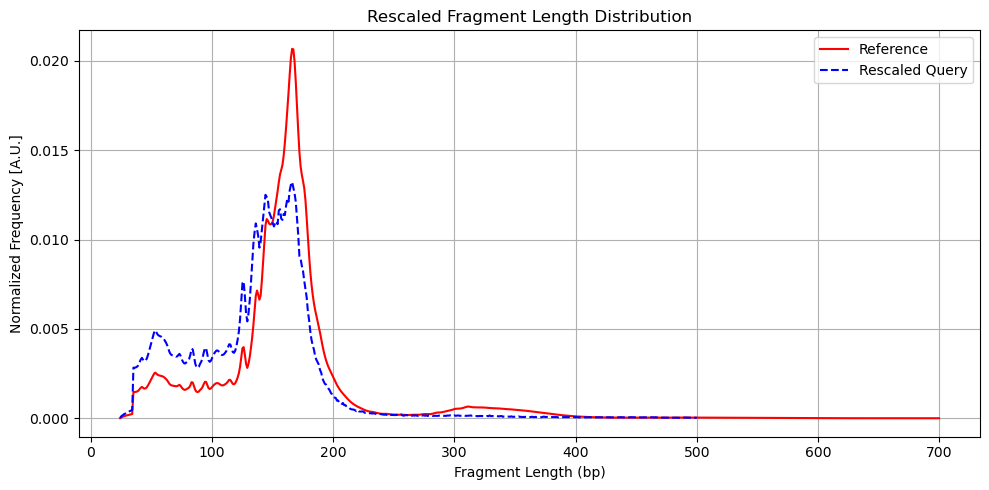

In [6]:
import matplotlib.pyplot as plt

# Set up the plot with a specified size
plt.figure(figsize=(10, 5))

# Reference distribution plot
ref_x = sorted(normalized_ref.keys())
ref_y = [normalized_ref[x] for x in ref_x]
plt.plot(ref_x, ref_y, label="Reference", color='red')

# Rescaled query distribution plot
plt.plot(x_vals, y_vals, label="Rescaled Query", color='blue', linestyle='dashed')

# Adding labels and title
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Rescaled Fragment Length Distribution")

# Display legend
plt.legend()

# Enable grid for better readability
plt.grid(True)

# Tightly fit the layout
plt.tight_layout()

# Display the plot
plt.show()
